In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

print(X.shape)
print(y.shape)
print(data.feature_names)
print(data.target_names)

(569, 30)
(569,)
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
['malignant' 'benign']


In [3]:
df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
df.shape

(569, 31)

In [5]:
df["target"].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("训练集：", X_train.shape)
print("测试集：", X_test.shape)

训练集： (455, 30)
测试集： (114, 30)


In [7]:
lgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    num_leaves=15,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_model.fit(X_train, y_train)

,num_leaves,15
,max_depth,3
,random_state,42
,n_jobs,-1
,verbose,-1
,boosting_type,'gbdt'
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [8]:
y_pred = lgbm_model.predict(X_test)

print("真实结果：", y_test[:20])
print("预测结果：", y_pred[:20])

真实结果： [0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1]
预测结果： [0 1 0 0 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1]


/home/penglei/projects/ml-learning/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [9]:
acc = accuracy_score(y_test, y_pred)

print("LightGBM 准确率：", acc)

LightGBM 准确率： 0.956140350877193


In [10]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[38  4]
 [ 1 71]]


In [11]:
print(classification_report(
    y_test,
    y_pred,
    target_names=data.target_names
))

              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [12]:
y_prob = lgbm_model.predict_proba(X_test)

print(y_prob[:5])

[[9.99888563e-01 1.11437365e-04]
 [6.16123577e-05 9.99938388e-01]
 [9.97073883e-01 2.92611658e-03]
 [9.56174334e-01 4.38256659e-02]
 [9.99944334e-01 5.56657017e-05]]


/home/penglei/projects/ml-learning/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [13]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    random_state=42
)

gbdt_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

lgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    num_leaves=15,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

In [14]:
rf_model.fit(X_train, y_train)
gbdt_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)
lgbm_model.fit(X_train, y_train)

,num_leaves,15
,max_depth,3
,random_state,42
,n_jobs,-1
,verbose,-1
,boosting_type,'gbdt'
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [15]:
rf_pred = rf_model.predict(X_test)
gbdt_pred = gbdt_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)
lgbm_pred = lgbm_model.predict(X_test)

/home/penglei/projects/ml-learning/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [16]:
print("随机森林准确率：", accuracy_score(y_test, rf_pred))
print("GBDT 准确率：", accuracy_score(y_test, gbdt_pred))
print("XGBoost 准确率：", accuracy_score(y_test, xgb_pred))
print("LightGBM 准确率：", accuracy_score(y_test, lgbm_pred))

随机森林准确率： 0.956140350877193
GBDT 准确率： 0.956140350877193
XGBoost 准确率： 0.9473684210526315
LightGBM 准确率： 0.956140350877193


In [17]:
feature_importance = pd.DataFrame({
    "feature": data.feature_names,
    "importance": lgbm_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(10)

,feature,importance
21,worst texture,64
27,worst concave points,51
1,mean texture,40
23,worst area,40
7,mean concave points,37
22,worst perimeter,35
24,worst smoothness,34
4,mean smoothness,30
28,worst symmetry,25
20,worst radius,24


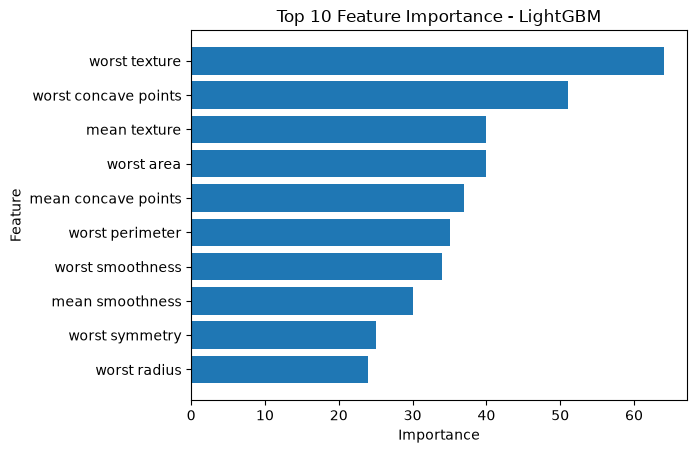

In [18]:
top_features = feature_importance.head(10)

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - LightGBM")
plt.gca().invert_yaxis()
plt.show()

In [19]:
n_values = [10, 50, 100, 200, 300]
accuracies = []

for n in n_values:
    model = LGBMClassifier(
        n_estimators=n,
        learning_rate=0.1,
        max_depth=3,
        num_leaves=15,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    accuracies.append(acc)

    print(f"n_estimators={n}, 准确率={acc:.4f}")

/home/penglei/projects/ml-learning/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


n_estimators=10, 准确率=0.9474


/home/penglei/projects/ml-learning/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


n_estimators=50, 准确率=0.9561


/home/penglei/projects/ml-learning/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


n_estimators=100, 准确率=0.9561


/home/penglei/projects/ml-learning/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


n_estimators=200, 准确率=0.9561
n_estimators=300, 准确率=0.9561


/home/penglei/projects/ml-learning/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


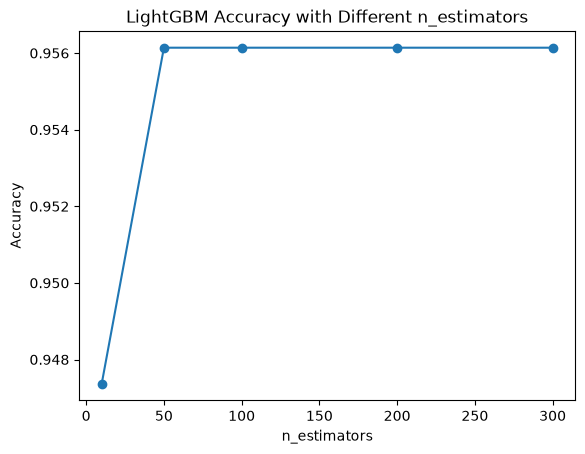

In [20]:
plt.plot(n_values, accuracies, marker="o")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.title("LightGBM Accuracy with Different n_estimators")
plt.show()

In [21]:
lr_values = [0.01, 0.05, 0.1, 0.2, 0.5]
accuracies = []

for lr in lr_values:
    model = LGBMClassifier(
        n_estimators=100,
        learning_rate=lr,
        max_depth=3,
        num_leaves=15,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    accuracies.append(acc)

    print(f"learning_rate={lr}, 准确率={acc:.4f}")

/home/penglei/projects/ml-learning/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


learning_rate=0.01, 准确率=0.9474


/home/penglei/projects/ml-learning/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


learning_rate=0.05, 准确率=0.9649


/home/penglei/projects/ml-learning/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


learning_rate=0.1, 准确率=0.9561
learning_rate=0.2, 准确率=0.9561
learning_rate=0.5, 准确率=0.9649


/home/penglei/projects/ml-learning/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/penglei/projects/ml-learning/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


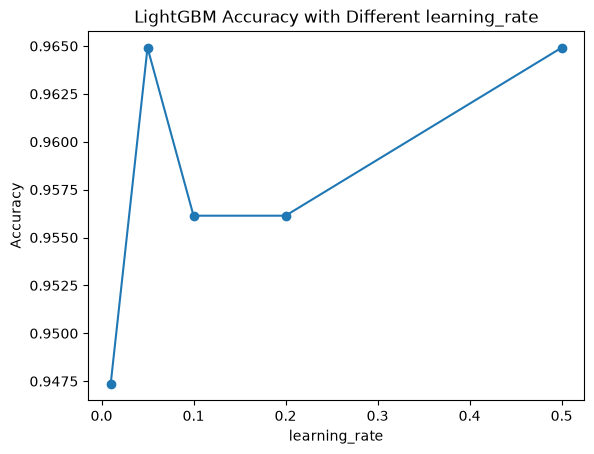

In [22]:
plt.plot(lr_values, accuracies, marker="o")
plt.xlabel("learning_rate")
plt.ylabel("Accuracy")
plt.title("LightGBM Accuracy with Different learning_rate")
plt.show()

In [23]:
leaf_values = [3, 7, 15, 31, 63]
accuracies = []

for leaves in leaf_values:
    model = LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=-1,
        num_leaves=leaves,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    accuracies.append(acc)

    print(f"num_leaves={leaves}, 准确率={acc:.4f}")

/home/penglei/projects/ml-learning/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


num_leaves=3, 准确率=0.9561


/home/penglei/projects/ml-learning/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


num_leaves=7, 准确率=0.9561


/home/penglei/projects/ml-learning/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


num_leaves=15, 准确率=0.9649


/home/penglei/projects/ml-learning/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


num_leaves=31, 准确率=0.9649
num_leaves=63, 准确率=0.9649


/home/penglei/projects/ml-learning/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


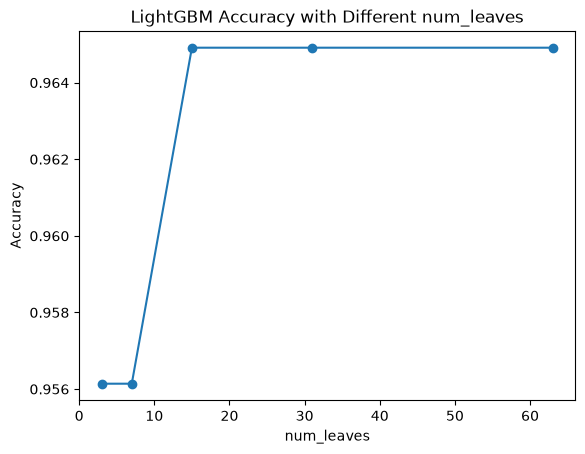

In [24]:
plt.plot(leaf_values, accuracies, marker="o")
plt.xlabel("num_leaves")
plt.ylabel("Accuracy")
plt.title("LightGBM Accuracy with Different num_leaves")
plt.show()